# NBA Data Story — Exploratory Data Analysis
**COM-480 Data Visualization — Milestone 1**  
Elias Mir · Michael Freeman · Yassine Mamlouk · Aziz Laadhar

## 0. Setup

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1526',
    'axes.facecolor':   '#111c30',
    'axes.edgecolor':   '#2a3555',
    'axes.labelcolor':  '#c8cfe0',
    'xtick.color':      '#6a7592',
    'ytick.color':      '#6a7592',
    'text.color':       '#e8e8f0',
    'grid.color':       '#1e2d47',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   10,
})

NBA_BLUE   = '#1D428A'
NBA_RED    = '#C8102E'
NBA_ORANGE = '#e8621a'
NBA_GOLD   = '#f5c518'

## 1. Load Data

Download the dataset from [Kaggle](https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats) and place the CSV files in a `data/` folder next to this notebook.

Key files used:
- `Player Per Game.csv`
- `Advanced.csv`
- `Team Summaries.csv`

In [24]:
per_game = pd.read_csv('data/Player Per Game.csv')
advanced = pd.read_csv('data/Advanced.csv')
teams    = pd.read_csv('data/Team Summaries.csv')

print(f'Per-game rows  : {len(per_game):,}')
print(f'Advanced rows  : {len(advanced):,}')
print(f'Team rows      : {len(teams):,}')
print()
print('Per-game columns:', list(per_game.columns[:12]), '...')

Per-game rows  : 33,278
Advanced rows  : 33,278
Team rows      : 1,907

Per-game columns: ['season', 'lg', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs', 'mp_per_game', 'fg_per_game', 'fga_per_game'] ...


## 2. Cleaning

In [25]:
# Remove mid-season trade duplicates

def drop_trade_dupes(df):
    mask_tot = df['team'] == 'TOT'
    multi    = df[df.duplicated(['player', 'season'], keep=False)]
    single   = df[~df.duplicated(['player', 'season'], keep=False)]
    return pd.concat([single, multi[mask_tot]]).reset_index(drop=True)

per_game = drop_trade_dupes(per_game)
advanced = drop_trade_dupes(advanced)

# Filter: meaningful playing time
per_game = per_game[(per_game['g'] >= 10) & (per_game['mp_per_game'] >= 10)].copy()
advanced = advanced[(advanced['g'] >= 10) & (advanced['mp'] / advanced['g'] >= 10)].copy()

# Merge per-game + advanced 
players = per_game.merge(
    advanced[['player','season','per','ts_percent','usg_percent','ows','dws','ws',
               'bpm','vorp','dbpm','obpm']],
    on=['player','season'], how='left'
)

# NBA only (post-merger, post-1976) 
players = players[players['season'] >= 1977].copy()
teams   = teams[teams['season']   >= 1977].copy()

print(f'Clean player-seasons : {len(players):,}')
print(f'Null values in key columns:')
key_cols = ['pts_per_game','trb_per_game','ast_per_game','ts_percent','usg_percent','vorp','per']
print(players[key_cols].isnull().sum().to_string())

Clean player-seasons : 14,924
Null values in key columns:
pts_per_game      0
trb_per_game      0
ast_per_game      0
ts_percent       19
usg_percent     240
vorp             19
per              19


## 3. Basic Statistics

In [26]:
# Dataset shape
print('=== DATASET OVERVIEW ===')
print(f'Seasons covered      : {players["season"].min()} – {players["season"].max()}')
print(f'Total player-seasons : {len(players):,}')
print(f'Unique players       : {players["player"].nunique():,}')
print(f'Teams per season avg : {teams.groupby("season")["abbreviation"].count().mean():.1f}')
print()

# Per-decade averages
players['decade'] = (players['season'] // 10) * 10
decade_stats = players.groupby('decade').agg(
    avg_pts   = ('pts_per_game',  'mean'),
    avg_ast   = ('ast_per_game',  'mean'),
    avg_ts    = ('ts_percent',    'mean'),
    avg_3pa   = ('x3pa_per_game', 'mean'),
    avg_usg   = ('usg_percent',   'mean'),
).round(2)
print('=== PER-DECADE PLAYER AVERAGES ===')
print(decade_stats.to_string())

=== DATASET OVERVIEW ===
Seasons covered      : 1977 – 2026
Total player-seasons : 14,924
Unique players       : 2,760
Teams per season avg : 27.6

=== PER-DECADE PLAYER AVERAGES ===
        avg_pts  avg_ast  avg_ts  avg_3pa  avg_usg
decade                                            
1970      11.09     2.56    0.51      NaN    19.26
1980      11.14     2.65    0.53     0.35    19.30
1990      10.37     2.40    0.52     1.18    19.18
2000       9.76     2.15    0.52     1.57    18.93
2010       9.94     2.18    0.54     2.24    19.05
2020      11.05     2.49    0.57     3.42    18.97


## 4. Visualizations

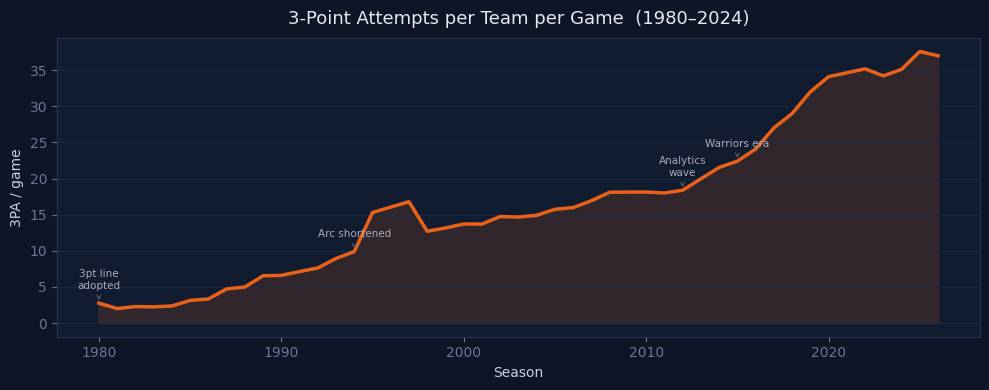

In [27]:
teams_pg = pd.read_csv('data/Team Stats Per Game.csv')
teams_pg = teams_pg[teams_pg['season'] >= 1980]
team_3pt = teams_pg.groupby('season')['x3pa_per_game'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(team_3pt.index, team_3pt.values, alpha=0.15, color=NBA_ORANGE)
ax.plot(team_3pt.index, team_3pt.values, color=NBA_ORANGE, lw=2.5)

events = {
    1980: ('3pt line\nadopted', 2),
    1994: ('Arc shortened', 2),
    2012: ('Analytics\nwave', 2),
    2015: ('Warriors era', 2),
}
for yr, (label, offset) in events.items():
    if yr in team_3pt.index:
        v = team_3pt[yr]
        ax.annotate(label, xy=(yr, v), xytext=(yr, v + offset),
                    fontsize=7.5, color='#aab', ha='center',
                    arrowprops=dict(arrowstyle='->', color='#556', lw=0.8))

ax.set_title('3-Point Attempts per Team per Game  (1980–2024)', pad=10)
ax.set_xlabel('Season')
ax.set_ylabel('3PA / game')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('fig1_three_point_revolution.png', dpi=150, bbox_inches='tight')
plt.show()

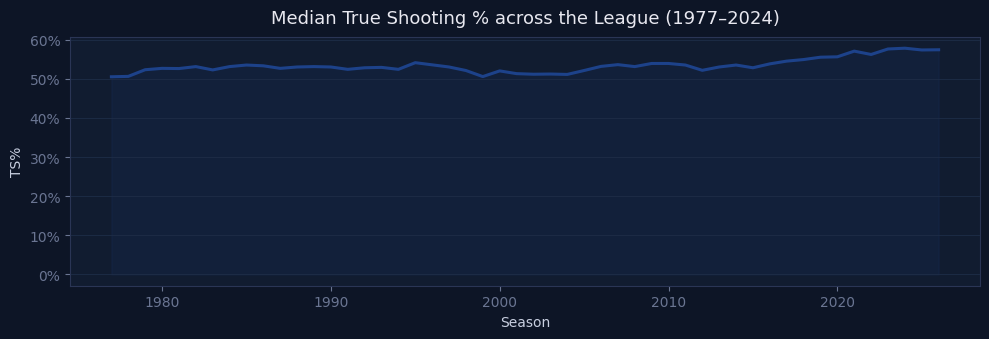

In [28]:
# Fig 2: True Shooting % evolution
ts_by_year = players.groupby('season')['ts_percent'].median()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(ts_by_year.index, ts_by_year.values * 100, color=NBA_BLUE, lw=2.2)
ax.fill_between(ts_by_year.index, ts_by_year.values * 100, alpha=0.12, color=NBA_BLUE)
ax.set_title('Median True Shooting % across the League (1977–2024)', pad=10)
ax.set_xlabel('Season'); ax.set_ylabel('TS%')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('fig2_true_shooting.png', dpi=150, bbox_inches='tight')
plt.show()

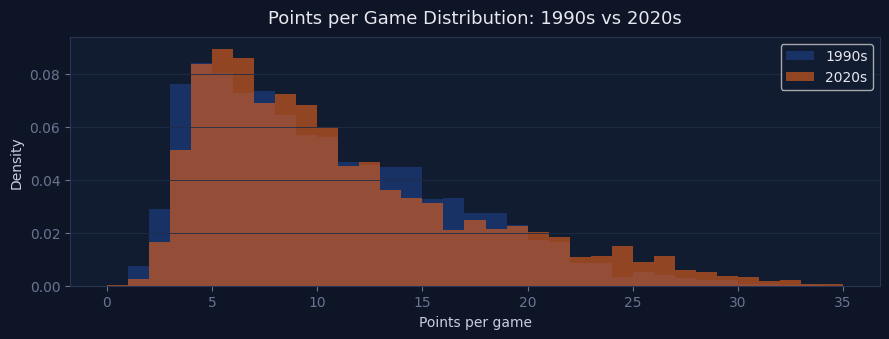

1990s mean pts/g: 10.37  |  skewness: 0.79
2020s mean pts/g: 11.05  |  skewness: 1.02


In [29]:
# Fig 3: Points per game distribution — 1990 vs 2020
pts_90 = players[players['decade'] == 1990]['pts_per_game']
pts_20 = players[players['decade'] == 2020]['pts_per_game']

fig, ax = plt.subplots(figsize=(9, 3.5))
bins = np.linspace(0, 35, 36)
ax.hist(pts_90, bins=bins, alpha=0.6, color=NBA_BLUE,   label='1990s', density=True)
ax.hist(pts_20, bins=bins, alpha=0.6, color=NBA_ORANGE, label='2020s', density=True)
ax.set_title('Points per Game Distribution: 1990s vs 2020s', pad=10)
ax.set_xlabel('Points per game'); ax.set_ylabel('Density')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('fig3_pts_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'1990s mean pts/g: {pts_90.mean():.2f}  |  skewness: {pts_90.skew():.2f}')
print(f'2020s mean pts/g: {pts_20.mean():.2f}  |  skewness: {pts_20.skew():.2f}')

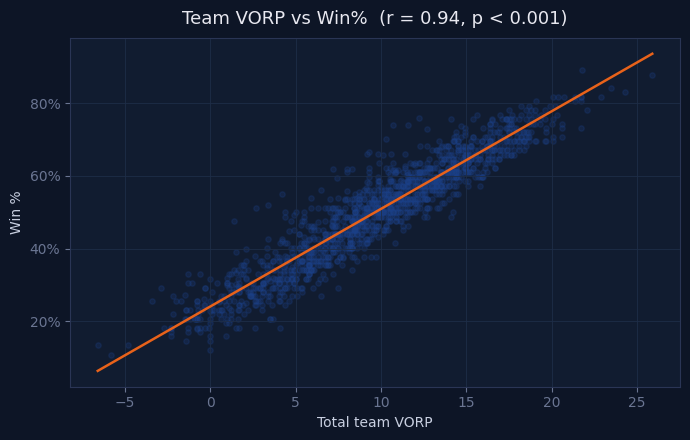

Pearson r = 0.938  |  p-value = 0.00e+00


In [30]:
# Fig 4: VORP vs Team Win % (validates advanced metrics)
# Sum VORP per team-season, join to team win%
team_vorp = players.groupby(['season','team'])['vorp'].sum().reset_index()
team_vorp.columns = ['season','abbreviation','total_vorp']

teams['win_pct'] = teams['w'] / (teams['w'] + teams['l'])
merged = team_vorp.merge(teams[['season','abbreviation','win_pct']], on=['season','abbreviation'])

from scipy import stats
r, p = stats.pearsonr(merged['total_vorp'], merged['win_pct'])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(merged['total_vorp'], merged['win_pct'],
           alpha=0.25, s=15, color=NBA_BLUE)
# Regression line
m, b = np.polyfit(merged['total_vorp'], merged['win_pct'], 1)
x_line = np.linspace(merged['total_vorp'].min(), merged['total_vorp'].max(), 100)
ax.plot(x_line, m*x_line + b, color=NBA_ORANGE, lw=1.8)
ax.set_title(f'Team VORP vs Win%  (r = {r:.2f}, p < 0.001)', pad=10)
ax.set_xlabel('Total team VORP'); ax.set_ylabel('Win %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True)
plt.tight_layout()
plt.savefig('fig4_vorp_vs_wins.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson r = {r:.3f}  |  p-value = {p:.2e}')

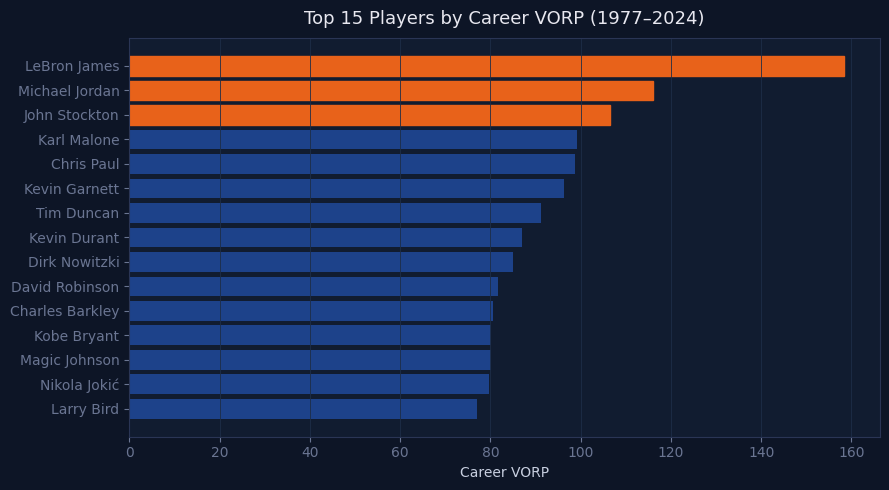

In [31]:
# Fig 5: Top 15 players by career VORP
career_vorp = (players.groupby('player')['vorp']
               .sum()
               .sort_values(ascending=False)
               .head(15))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(career_vorp.index[::-1], career_vorp.values[::-1],
               color=NBA_BLUE, edgecolor='none')
# Highlight top 3
for bar in bars[-3:]:
    bar.set_color(NBA_ORANGE)

ax.set_title('Top 15 Players by Career VORP (1977–2024)', pad=10)
ax.set_xlabel('Career VORP')
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('fig5_career_vorp.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary Table (for PDF)

Numbers reported in the milestone document.

In [34]:
def era_avg(df, teams_pg_df, teams_summary_df, start, end, label):
    p  = df[(df['season'] >= start) & (df['season'] <= end)]
    tg = teams_pg_df[(teams_pg_df['season'] >= start) & (teams_pg_df['season'] <= end)]
    ts = teams_summary_df[(teams_summary_df['season'] >= start) & (teams_summary_df['season'] <= end)]
    return {
        'Era':       label,
        '3PA/game':  round(tg['x3pa_per_game'].mean(), 1),
        'Pace':      round(ts['pace'].mean(), 1),
        'Avg TS%':   f"{round(p['ts_percent'].mean()*100, 1)}%",
        'Avg PTS/g': round(p['pts_per_game'].mean(), 1),
    }

summary = pd.DataFrame([
    era_avg(players, teams_pg, teams, 1980, 1989, '1980s'),
    era_avg(players, teams_pg, teams, 1990, 1999, '1990s'),
    era_avg(players, teams_pg, teams, 2000, 2009, '2000s'),
    era_avg(players, teams_pg, teams, 2010, 2019, '2010s'),
    era_avg(players, teams_pg, teams, 2020, 2024, '2020s'),
])
print(summary.to_string(index=False))

  Era  3PA/game  Pace Avg TS%  Avg PTS/g
1980s       3.5 101.5   52.9%       11.1
1990s      11.5  93.8   52.5%       10.4
2000s      15.7  91.4   52.0%        9.8
2010s      23.1  94.5   53.6%        9.9
2020s      34.6  99.1   56.8%       10.9
